# **Linear Regression**


Linear Regression is a method to find a relationship between input variables (features) and an output variable (target).

***Importing Basic Libraries***

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

**How can we load it in Python using pandas and see the first few rows?**.

In [33]:
df = pd.read_csv('Food_Delivery_Times.csv')
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## Exploring the Data**

Check your dataset by some of the commands to quickly see its size, column names, missing values, and basic statistics.

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [35]:
df.shape

(1000, 9)

In [36]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [37]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


### Handling Null Values
Fill the missing values in the categorical columns by replacing them with the most frequent value in each column.

In [38]:
cols = ['Weather', 'Traffic_Level', 'Time_of_Day']

In [39]:
for i in cols:
  df[i] = df[i].fillna(df[i].mode()[0])

In [40]:
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean())

<Axes: xlabel='Courier_Experience_yrs', ylabel='Density'>

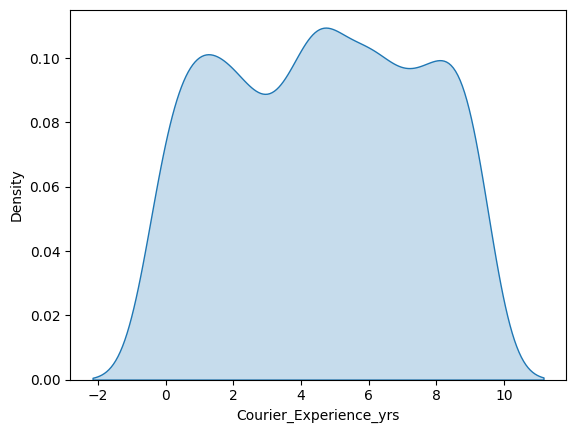

In [41]:
import seaborn as sns
sns.kdeplot(df['Courier_Experience_yrs'],fill = True)

## Visualizing the Data
Visualize the relationships between all pairs of variables in the dataset to see patterns and correlations.

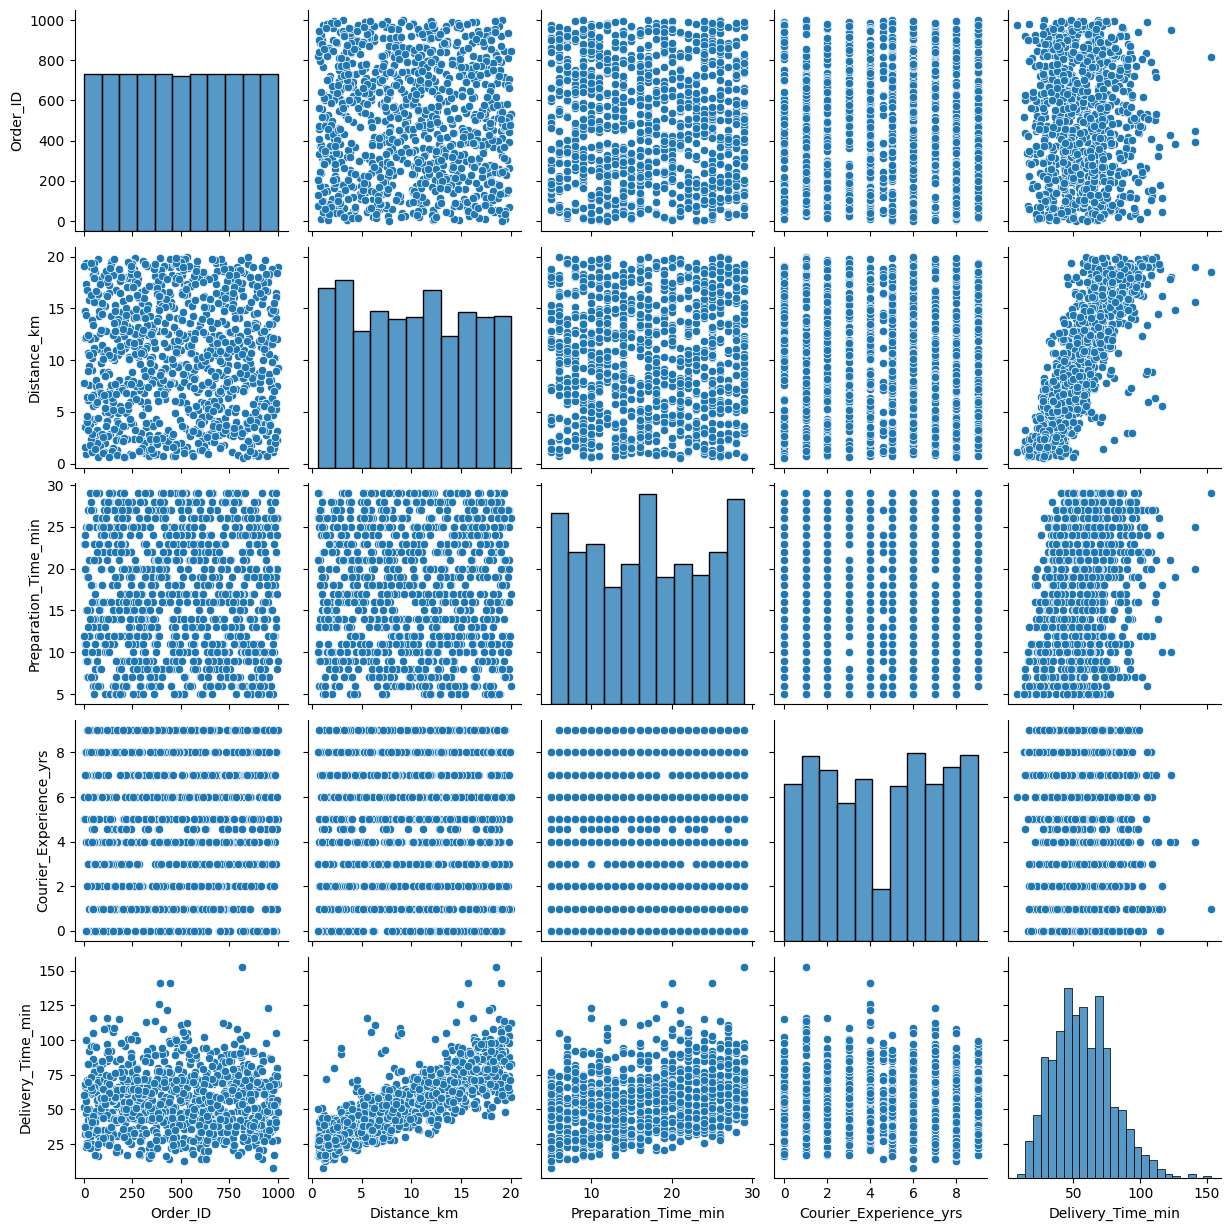

In [42]:
sns.pairplot(df)

### Mapping Values
Linear Regression works only on numeric data, so we need to convert categorical columns into numbers.

In [43]:
df_encoded = df.copy()

In [44]:
cols = ['Weather', 'Traffic_Level', 'Time_of_Day','Vehicle_Type']

In [45]:
df_dummies = pd.get_dummies(df_encoded, columns= cols)

In [46]:
df_dummies = df_dummies.astype(float)

In [47]:
df_dummies.head()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522.0,7.93,12.0,1.0,43.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,738.0,16.42,20.0,2.0,84.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,741.0,9.52,28.0,1.0,59.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,661.0,7.44,5.0,1.0,37.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,412.0,19.03,16.0,5.0,68.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [48]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Weather'] = le.fit_transform(df['Weather'])
df['Traffic_Level'] = le.fit_transform(df['Traffic_Level'])
df['Time_of_Day'] = le.fit_transform(df['Time_of_Day'])
df['Vehicle_Type'] = le.fit_transform(df['Vehicle_Type'])

In [49]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,4,1,0,2,12,1.0,43
1,738,16.42,0,2,1,0,20,2.0,84
2,741,9.52,1,1,3,2,28,1.0,59
3,661,7.44,2,2,0,2,5,1.0,37
4,412,19.03,0,1,2,0,16,5.0,68


## **Defining Features and Target**

X (features) → known factors (distance, traffic, weather, etc.)

y (target) → what we want to predict (delivery time)


In [50]:
y = df['Delivery_Time_min']
X = df.drop(['Delivery_Time_min', 'Order_ID'], axis = 1)

## Splitting Data into Train and Test Sets**

How can we check how well our model performs on unseen data?
Why do we split the dataset into two parts:

Training set (80%) → used to train the model

Testing set (20%) → used to evaluate the modelbrary.


In [51]:
from sklearn.model_selection import train_test_split

In [52]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Training the Linear Regression Model**


In [53]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()


In [54]:
model.fit(x_train, y_train)

LinearRegression()

## Making Predictions

Use the trained model to predict delivery times for the test data.

In [68]:
y_pred = model.predict(x_test)

In [65]:
y_test

,Delivery_Time_min
521,32
737,68
740,39
660,44
411,85
...,...
506,75
342,66
485,86
711,57


In [75]:
model.predict(x_test.iloc[[1]])

array([64.27934305])

In [72]:
# Accuracy
model.score(x_test, y_test)*100

75.5707133911987

In [76]:
import pickle
from google.colab import files

# Create a dummy dictionary to pickle
dummy_data = {'name': 'example', 'value': 123, 'list': [1, 2, 3]}

# Specify the filename for the pickle file
filename = 'dummy_data.pkl'

# Save the dictionary to a pickle file
with open(filename, 'wb') as f:
    pickle.dump(dummy_data, f)

print(f"'{filename}' created successfully.")

'dummy_data.pkl' created successfully.


In [77]:
# Download the pickle file
files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Evaluating the Model**

Check how accurate your predictions are by calculating the average error, squared error, and R² score.


In [57]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [58]:
mean_absolute_error(y_test, y_pred)

7.319260043004716

In [59]:
mean_squared_error(y_test, y_pred)

118.58120186951419

In [60]:
r2 = r2_score(y_test, y_pred)

In [61]:
n = x_test.shape[0]
p = x_test.shape[1]
adjusted_r2 = 1-((1-r2) * (n-1))/(n-p-1)


In [62]:
adjusted_r2

0.7503964194318128

### **Visualizing Predictions**


Create a scatter plot to compare actual vs predicted delivery times and visually check how well the model is performing.


### Ridge Regression
Train a Ridge regression model on the training data, predict delivery times for the test set, and evaluate its accuracy using MAE, MSE, and R².

### Lasso Regression
Train a Lasso regression model on your training data, predict delivery times for the test set, and check how accurate the predictions are using MAE, MSE, and R².

### Polynomial Regression
Transform your features to include polynomial terms, train a Linear Regression model on them, and calculate the mean squared error to see how well the curved model fits your data.

# Conclusion
-Predicted food delivery times using features like distance, traffic, weather, time, and courier experience.

-Applied Linear Regression for basic predictions.

-Used Ridge and Lasso to reduce overfitting and improve accuracy.

-Explored Polynomial Regression to capture nonlinear relationships.

-Evaluated models with MAE, MSE, and R² to measure performance.

-Demonstrated a real-world application of regression in optimizing delivery operations.